## Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("C:/Users/hp/VR-PROJECTS/zomato-restaurant-analysis/data/zomato.csv")
cuisines = pd.read_csv('C:/Users/hp/VR-PROJECTS/zomato-restaurant-analysis/data/zomato_cuisines.csv')
rated = df[df['Aggregate rating'] > 0].copy()
sns.set_style('whitegrid')
print(df.shape, rated.shape)


(9551, 21) (7403, 21)


## Rating ka Distribution

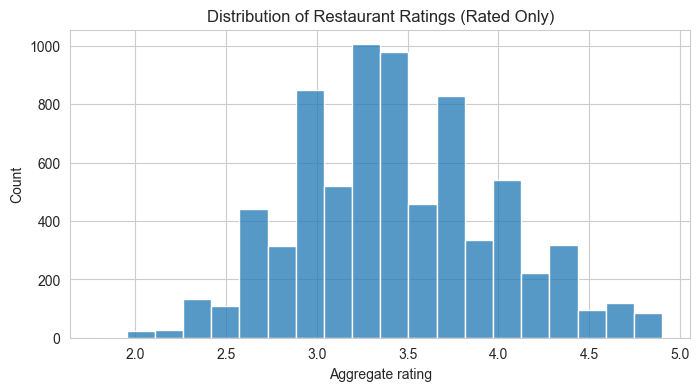

count    7403.000000
mean        3.440024
std         0.552195
min         1.800000
25%         3.000000
50%         3.400000
75%         3.800000
max         4.900000
Name: Aggregate rating, dtype: float64


In [13]:
plt.figure(figsize=(8,4))
sns.histplot(rated['Aggregate rating'],bins=20)
plt.title('Distribution of Restaurant Ratings (Rated Only)')
plt.show()
print(rated['Aggregate rating'].describe())

## Top 10 localities(by rating)

In [18]:
loc = rated.groupby('Locality').agg(
    restaurants=('Restaurant ID','count'),
    avg_rating=('Aggregate rating','mean'),
    median_cost=('Average Cost for two','median')
).query('restaurants >= 30').sort_values('avg_rating', ascending=False).head(10)
loc

,restaurants,avg_rating,median_cost
Locality,,,
"Cyber Hub, DLF Cyber City",41,3.860976,1400.0
"DLF Mall of India, Sector 18, Noida",31,3.841935,750.0
Sector 29,44,3.813636,1400.0
Khan Market,43,3.802326,1300.0
Connaught Place,119,3.779832,1200.0
Greater Kailash (GK) 1,66,3.696970,800.0
Vijay Nagar,46,3.663043,575.0
Rajouri Garden,98,3.628571,725.0
Janpath,33,3.572727,750.0


## Price Aur Rating ka Rishta

                      Average Cost for two  Aggregate rating     Votes
Average Cost for two              1.000000          0.076790  0.063424
Aggregate rating                  0.076790          1.000000  0.409018
Votes                             0.063424          0.409018  1.000000


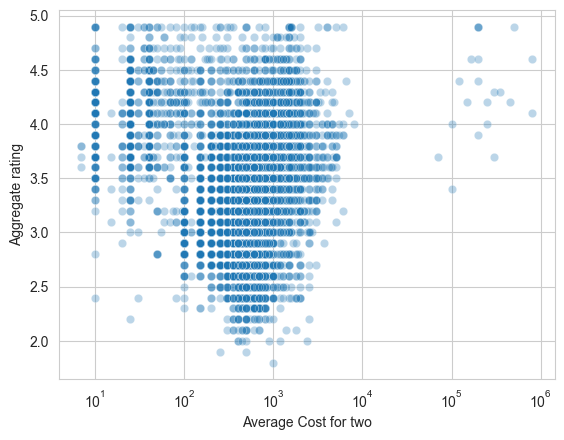

In [20]:
print(rated[['Average Cost for two', 'Aggregate rating', 'Votes']].corr())
sns.scatterplot(data=rated, x='Average Cost for two', y='Aggregate rating', alpha=0.3)
plt.xscale('log')
plt.show()

## Online delivery aur table booking

In [21]:
print(rated.groupby('Has Online delivery')['Aggregate rating'].agg(['mean','median','count']))
print(rated.groupby('Has Table booking')['Aggregate rating'].agg(['mean','median','count']))

                         mean  median  count
Has Online delivery                         
No                   3.467433     3.4   5048
Yes                  3.381274     3.4   2355
                       mean  median  count
Has Table booking                         
No                 3.413970     3.4   6292
Yes                3.587579     3.6   1111


## Top cuisines

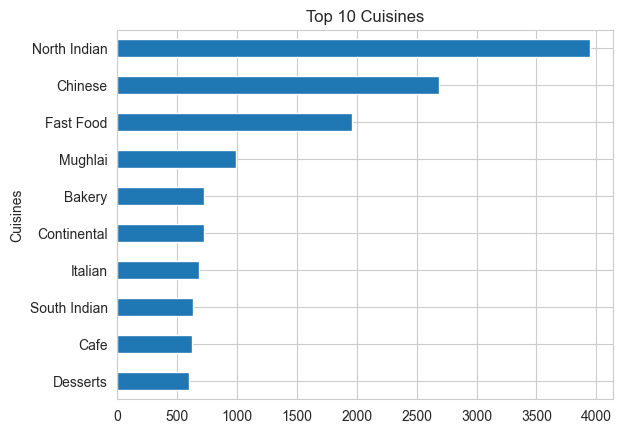

In [23]:
top = cuisines['Cuisines'].value_counts().head(10)
top.plot(kind='barh', title='Top 10 Cuisines')
plt.gca().invert_yaxis()
plt.show()